<a href="https://colab.research.google.com/github/KowshiqKatta/ML_Implementations/blob/main/ADABOOST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns = iris.feature_names)
df['target'] = iris.target

In [4]:
X = df.drop('target', axis = 1)
y = df['target']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [6]:
ada_clf = AdaBoostClassifier(n_estimators = 50, learning_rate = 0.1, random_state = 42)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(learning_rate=0.1, random_state=42)

In [7]:
y_pred = ada_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [9]:
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 100.00%


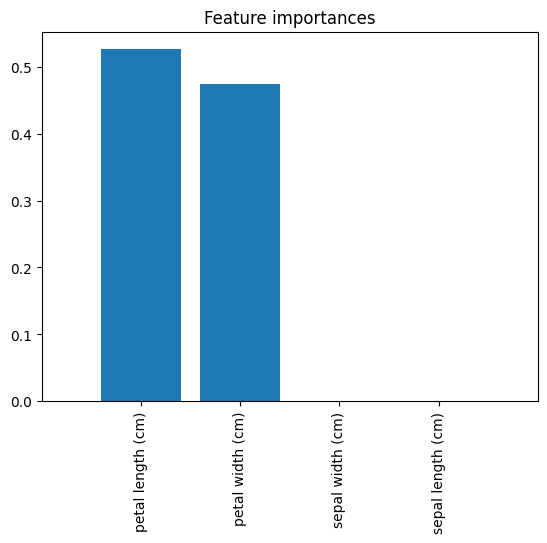

In [10]:
importances = ada_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices], align = "center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation = 90)
plt.xlim([-1, X.shape[1]])

plt.show()